### Create clean dataset

This script will take out all the heavily modified samples in the SCSS-net dataset.

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import zarr
from datetime import datetime
from skimage.transform import resize

1) show alignement of two png

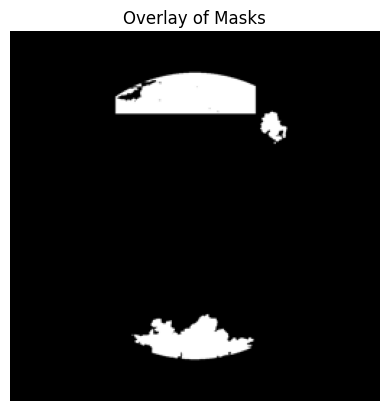

(256, 256)


In [22]:
name_img = r"2018_04_25__03_44_28_84__SDO_AIA_AIA_193" + r".png"

# #images_sure
# path_folder_img = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\imagesTs_sure" + r"/"
# path_folder_label = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\labelsTs_sure" + r"/"

# #general
# path_folder_img = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\imagesTs" + r"/"
# path_folder_label = r"C:\Users\User\Master_physics\Space_weather\scss-net\data\193_train_adapted\193(region_growth)\labelsTs" + r"/"

#New download

path_folder_img = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193\193_train\193(region_growth)\imgs" + r"/"
path_folder_label = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\193\193_train\193(region_growth)\masks" + r"/"


# img = np.array(Image.open(path_folder_img + name_img).convert("L"))
label = np.array(Image.open(path_folder_label + name_img).convert("L"))
# plt.imshow(img, cmap="hot")
#plt.imshow(label, cmap="Blues", alpha=0.5)
plt.imshow(label,cmap ="gray")
plt.title("Overlay of Masks")
plt.axis("off")
plt.show()

# print(img.shape)
print(label.shape)


2) Loop over parts of the folder to look at each sample individually

if the sample is bad, i delete it from the label and note the title of the bad sample in a list.

In [ ]:
start_name = "2013_01_02__01_38_47_34__SDO_AIA_AIA_171.png"
add_idx = 300


path_folder_label = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(spoca)\masks" + r"/"
path_folder_img = r"C:\Users\User\Master_physics\Master_Thesis\SCSS-net data 30-01-2026\171\171_train\171(spoca)\imgs" + r"/"

# Get sorted list of image filenames
image_files = sorted([f for f in os.listdir(path_folder_img) if f.endswith(".png")])
image_files_subset = image_files[::4]
start_idx = image_files_subset.index(start_name)
image_files_subset_300 = image_files_subset[start_idx : start_idx + add_idx]


#from:2013_05_18__23_00_06_84__SDO_AIA_AIA_193
for name_img in image_files_subset_300:
    img = np.array(Image.open(os.path.join(path_folder_img, name_img)).convert("L"))
    label = np.array(Image.open(os.path.join(path_folder_label, name_img)).convert("L"))

    # Plot overlay
    plt.imshow(img, cmap="hot")
    plt.imshow(label, cmap="Blues", alpha=0.5)
    plt.title(f"{name_img}")
    plt.axis("off")
    plt.show()


3) Use the list to delete the files in the image folder

In [ ]:
image_names = [
    "2012_03_15__23_00_07_84__SDO_AIA_AIA_193",
    "2013_05_21__22_59_44_78__SDO_AIA_AIA_193",
    "2013_09_27__22_59_54_84__SDO_AIA_AIA_193",
    "2013_11_10__00_00_18_84__SDO_AIA_AIA_193",
    "2013_11_11__00_00_30_84__SDO_AIA_AIA_193",
    "2013_11_11__23_00_06_84__SDO_AIA_AIA_193",
    "2013_12_11__23_59_42_84__SDO_AIA_AIA_193",
    "2013_12_16__16_30_06_84__SDO_AIA_AIA_193",
    "2013_12_19__23_00_06_84__SDO_AIA_AIA_193",
    "2013_12_21__11_34_07_62__SDO_AIA_AIA_193",
    "2014_01_11__22_59_54_84__SDO_AIA_AIA_193",
    "2014_01_12__22_59_42_84__SDO_AIA_AIA_193",
    "2014_03_11__22_58_42_84__SDO_AIA_AIA_193",
    "2014_06_24__22_59_42_84__SDO_AIA_AIA_193",
    "2014_07_26__22_59_54_84__SDO_AIA_AIA_193",
    "2014_08_31__22_59_42_84__SDO_AIA_AIA_193",
    "2014_09_07__22_59_54_84__SDO_AIA_AIA_193",
    "2014_09_25__22_59_42_84__SDO_AIA_AIA_193",
    "2014_09_26__22_59_54_84__SDO_AIA_AIA_193",
    "2014_09_27__22_59_42_84__SDO_AIA_AIA_193",
    "2014_10_14__22_59_42_84__SDO_AIA_AIA_193",
    "2014_11_07__06_05_30_84__SDO_AIA_AIA_193",
    "2014_11_08__22_59_42_84__SDO_AIA_AIA_193",
    "2014_11_12__22_59_54_84__SDO_AIA_AIA_193",
    "2014_11_14__22_59_54_84__SDO_AIA_AIA_193",
    "2015_02_26__23_00_06_84__SDO_AIA_AIA_193",
    "2015_03_04__22_59_54_84__SDO_AIA_AIA_193",
    "2015_05_15__22_59_54_84__SDO_AIA_AIA_193",
    "2015_07_06__23_00_17_84__SDO_AIA_AIA_193",
    "2015_07_29__23_00_17_84__SDO_AIA_AIA_193",
    "2015_09_06__23_00_05_84__SDO_AIA_AIA_193",
    "2015_09_14__23_00_17_84__SDO_AIA_AIA_193",
    "2015_09_15__23_00_05_84__SDO_AIA_AIA_193",
    "2015_09_16__23_00_05_84__SDO_AIA_AIA_193",
    "2015_12_07__23_00_17_84__SDO_AIA_AIA_193",
    "2015_12_29__23_00_17_84__SDO_AIA_AIA_193",
    "2016_01_01__23_00_17_84__SDO_AIA_AIA_193",
    "2016_01_25__23_00_17_84__SDO_AIA_AIA_193",
    "2016_01_26__22_59_53_84__SDO_AIA_AIA_193",
    "2016_03_05__22_59_53_84__SDO_AIA_AIA_193",
    "2016_03_06__22_59_53_84__SDO_AIA_AIA_193",
    "2016_03_07__23_00_17_84__SDO_AIA_AIA_193",
    "2016_03_08__23_00_17_84__SDO_AIA_AIA_193",
    "2016_03_19__23_00_17_84__SDO_AIA_AIA_193",
    "2016_05_09__22_59_53_84__SDO_AIA_AIA_193",
    "2016_05_26__22_59_53_84__SDO_AIA_AIA_193",
    "2016_06_05__22_59_53_84__SDO_AIA_AIA_193",
    "2016_06_20__22_59_53_84__SDO_AIA_AIA_193",
    "2016_08_17__22_59_53_84__SDO_AIA_AIA_193",
    "2016_08_18__23_00_17_84__SDO_AIA_AIA_193",
    "2016_10_09__22_59_53_84__SDO_AIA_AIA_193",
    "2016_10_10__23_00_05_84__SDO_AIA_AIA_193",
    "2016_10_12__22_59_53_84__SDO_AIA_AIA_193",
    "2016_10_24__22_59_53_85__SDO_AIA_AIA_193",
    "2016_10_25__23_00_17_84__SDO_AIA_AIA_193",
    "2016_11_01__22_59_53_84__SDO_AIA_AIA_193",
    "2016_11_13__22_59_41_84__SDO_AIA_AIA_193",
    "2016_11_15__23_00_17_84__SDO_AIA_AIA_193",
    "2016_11_21__22_59_41_84__SDO_AIA_AIA_193",
    "2016_11_27__22_59_41_84__SDO_AIA_AIA_193",
    "2016_12_01__23_00_05_84__SDO_AIA_AIA_193",
    "2018_02_19__05_32_40_84__SDO_AIA_AIA_193",
    "2018_03_29__05_48_40_84__SDO_AIA_AIA_193",
    "2018_03_30__05_32_28_84__SDO_AIA_AIA_193",
    "2018_03_31__03_45_28_84__SDO_AIA_AIA_193",
    "2018_04_01__04_00_40_84__SDO_AIA_AIA_193",
    "2018_04_02__04_13_40_85__SDO_AIA_AIA_193",
    "2018_04_16__03_58_40_84__SDO_AIA_AIA_193",
    "2018_04_18__03_32_28_84__SDO_AIA_AIA_193",
    "2018_04_19__04_19_16_84__SDO_AIA_AIA_193",
    "2018_04_20__04_13_16_84__SDO_AIA_AIA_193",
    "2018_04_21__03_28_16_84__SDO_AIA_AIA_193",
    "2018_04_22__03_57_28_84__SDO_AIA_AIA_193",
    "2018_04_23__03_28_40_85__SDO_AIA_AIA_193",
    "2018_04_25__03_44_28_84__SDO_AIA_AIA_193",
    "2018_04_29__02_44_16_84__SDO_AIA_AIA_193",
    "2018_05_05__03_26_16_84__SDO_AIA_AIA_193",
    "2018_05_09__06_25_04_84__SDO_AIA_AIA_193",
    "2018_05_10__03_43_16_84__SDO_AIA_AIA_193",
    "2018_05_15__04_13_16_84__SDO_AIA_AIA_193",
    "2018_05_28__02_28_16_83__SDO_AIA_AIA_193",
    "2018_06_29__12_00_04_84__SDO_AIA_AIA_193",
]


4) Here we delete the file

In [ ]:
deleted = 0
missing = []

# Suffix = "", "_r90", "_r180", "_r270"    <- INSERT_A_SUFFIX
for name in image_names:
    filename = name + "INSERT_A_SUFFIX"+".png"
    filepath = os.path.join(path_folder_img, filename)

    if os.path.exists(filepath):
        os.remove(filepath)
        deleted += 1
    else:
        missing.append(filename)

print(f"Deleted {deleted} files.")

if missing:
    print("Files not found (nothing deleted):")
    for m in missing:
        print("  ", m)

Deleted 82 files.


In [42]:
label_files = sorted([f for f in os.listdir(path_folder_label) if f.endswith(".png")])

print(len(label_files))
print(len(image_files))

# Missing in images
missing_in_images = sorted(list(set(label_files) - set(image_files)))

# Missing in labels
missing_in_labels = sorted(list(set(image_files) - set(label_files)))

print("❌ Files in labelsTs missing in imagesTs (with indexes):")
for idx, f in enumerate(missing_in_images):
    print(f"{idx}: {f}")

print("\n❌ Files in imagesTs missing in labelsTs (with indexes):")
for idx, f in enumerate(missing_in_labels):
    print(f"{idx}: {f}")

print("\nDone.")

7544
7544
❌ Files in labelsTs missing in imagesTs (with indexes):

❌ Files in imagesTs missing in labelsTs (with indexes):

Done.
